NOMBRE: ALEJANDRO JOSE GOMEZ HERNANDEZ


CARNE: 20347


FECHA: 12/10/2024


**Objetivo**: La idea de esta práctica es que exploren el desarrollo de un proceso de cuatización. Para esto, deben cubrir lo que se vio en clase:
1. Efectuar el proceso de cuantización.
2. Determinar su error.

In [3]:
!pip install torch

In [4]:
import torch
from torch import tensor


In [5]:
test_tensor = tensor([[-0.6870,  0.2607, -0.7718,  0.0841],
                       [ 0.6558, -1.1711, -1.0713,  0.2405],
                       [ 1.4967, -0.6928,  0.7961, -1.4614],
                       [ 0.5689, -0.5227, -1.3111, -0.8343]])

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
def calcular_escala_zero_point(tensor_data, qmin=-128, qmax=127):
    rmin, rmax = tensor_data.min().item(), tensor_data.max().item()

    scale = (rmax - rmin) / (qmax - qmin)
    zero_point = qmin - (rmin / scale)
    zero_point = max(qmin, min(qmax, int(zero_point)))
    scale /= 4
    return scale, zero_point


In [8]:
def cuantizar_tensor(tensor_data, scale, zero_point):
    tensor_cuantizado = torch.round(tensor_data / scale + zero_point).clip(-128, 127)
    return tensor_cuantizado.to(torch.int8)

In [9]:
def descuantizar_tensor(tensor_cuantizado, scale, zero_point):
    tensor_descuantizado = (tensor_cuantizado.float() - zero_point) * scale
    return tensor_descuantizado

In [10]:
def graficar_cuantizacion(tensor_data, tensor_cuantizado, tensor_descuantizado):
    df = pd.DataFrame({
        'Original': tensor_data.view(-1).numpy(),
        'Cuantizado': tensor_cuantizado.view(-1).numpy(),
        'Descuantizado': tensor_descuantizado.view(-1).numpy()
    })

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, dashes=False)
    plt.title('Proceso de Cuantización')
    plt.xlabel('Elementos')
    plt.ylabel('Valores')
    plt.legend(['Original', 'Cuantizado', 'Descuantizado'])
    plt.show()

In [11]:
#Así como se vio en clase, definan una proceso de linear quantization para test_tensor
#Para llevar esto a acabo, debe encontrar la escala: scale = rmax-rmin/qmax-qmin.
#Trabajando con pytorch int8 (para mapear a int4) qmax=127 y qmin=128.
#zero_point = qmin-(rmin/scale).
#Con esta informacion ya pueden proceder a trabaja la cuantización lineal.


escala, zero_point = calcular_escala_zero_point(test_tensor, qmin=-128, qmax=127)

# Cuantizar y descuantizar el tensor
tensor_cuantizado = cuantizar_tensor(test_tensor, escala, zero_point)
tensor_descuantizado = descuantizar_tensor(tensor_cuantizado, escala, zero_point)



In [18]:
print("Tensor Cuantizado:", tensor_cuantizado)
print("Tensor Descuantizado:", tensor_descuantizado)

Tensor Cuantizado: tensor([[-78, -77, -78, -76],
        [-77, -78, -77, -77],
        [-77, -78, -77, -78],
        [-77, -78, -78, -78]], dtype=torch.int8)
Tensor Descuantizado: tensor([[-0.3654,  0.2610, -0.3654,  0.0841],
        [ 0.3741, -0.3654, -0.3654,  0.2407],
        [ 0.3741, -0.3654,  0.3741, -0.3654],
        [ 0.3741, -0.3654, -0.3654, -0.3654]])


In [13]:
#Resultado del tensor cuantizado:
quantized_tensor = tensor([[-77, -77, -77, -77],
                           [-77, -77, -77, -77],
                           [-77, -77, -77, -77],
                           [-77, -77, -77, -77]], dtype=torch.int8)
#Resultado del tensor descuantizado:
deq_tensor = tensor([[0., 0., 0., 0.],
                     [0., 0., 0., 0.],
                     [0., 0., 0., 0.],
                     [0., 0., 0., 0.]])


Con la parte anterior correcta, ya pueden proceder a trabajar lo siguiente:

1. Investigar Symmetric mode quantization.
2. per-channel quantization.
3. per-group quantization.

Para cada uno de estos, explicar su funcionamiento y cuando puede ser conveniente usarlos respecto a las otras técnicas.

Finalmente, desarrollar cada uno de la misma manera en que se trabajo la cuantización lineal. (Estos tres son casos especiales de la cuantización lineal, por lo que deberían solo hacer cambios especificos al código de la primera parte).


Responda la siguiente pregunta: ¿Aquí estamos trabajando post-training quantization o quantization-aware training?

### 📏 Symmetric Mode Quantization

Es un método en el que los valores se cuantizan alrededor de un centro cero simétrico, es decir, los valores positivos/negativos tienen mismo rango absoluto. Útil cuando el rango de datos está equilibrado y el modelo puede tolerar que los valores cuantizados se distribuyan de forma uniforme en ambos lados del cero.

#### 🚀 ¿Cómo funciona?

1. **Escala Uniforme**: Se utiliza una sola escala (`scale`) para todo el rango de valores, tanto positivos como negativos.
2. **Zero Point en Cero**: Como es simétrico, el zero point (`zero_point`) se fija en `0`.
3. **Fórmula**:
   ```python
   quantized_value = round(real_value / scale)


### 🔀 Per-Channel Quantization

Es un método en el que cada canal se cuantiza utilizando una escala y un zero point independientes. Esto permite que cada canal ajuste su rango de cuantización en función de sus características específicas, lo que mejora la precisión en comparación con el método global.

#### 🚀 ¿Cómo funciona?

1. **Escala por canal**: Cada canal obtiene su propia scale y zero_point, lo que permite que los valores dentro de cada canal se ajusten mejor a sus propios rangos de datos.
2. **Zero Point por canal**: Similarmente, cada canal puede tener su propio zero point, aunque en algunos casos se fija en 0.
3. **Fórmula**:
   ```python
   quantized_value = round(real_value / scale[channel]) + zero_point[channel]



### 🔗 Per-Group Quantization

Es una extensión de la cuantización por canal, donde los canales se agrupan en bloques, y cada bloque tiene su propia scale y zero_point. Esto ofrece un balance entre la granularidad de la cuantización por canal y la eficiencia de la cuantización global. Es útil cuando los recursos son limitados, pero se requiere cierta adaptabilidad para diferentes distribuciones de valores en distintos grupos de canales

#### 🚀 ¿Cómo funciona?

1. **Agrupamiento de canal**: Los canales se dividen en grupos, y cada grupo tiene un único scale y zero_point.
2. **Escala y Zero Point por grupo**: Cada grupo se cuantiza utilizando su propio scale y zero_point, lo que permite ajustes más precisos dentro de cada grupo.
3. **Fórmula**:
   ```python
  quantized_value = round(real_value / scale[group]) + zero_point[group]




### 🥇 1. Per-Channel Quantization

La **cuantización por canal** es la técnica más granular y precisa. Permite que cada canal tenga su propio rango de cuantización, lo cual maximiza la adaptación del modelo a variaciones específicas en los datos de cada canal. Esto es especialmente beneficioso en redes convolucionales profundas y modelos de redes neuronales donde cada canal puede representar características distintas.

#### 🔹 Cuándo usarlo:
- **Modelos de Alta Precisión**: Cuando la precisión es crucial y el modelo debe capturar diferentes rangos de activaciones.
- **Redes Convolucionales**: Ideal para CNNs con múltiples filtros, ya que cada filtro puede cuantizarse independientemente.
- **Hardware Suficiente**: Requiere más recursos, así que es preferible en hardware con suficiente capacidad de procesamiento.

#### ⚖️ Comparado con las otras técnicas:
- **Vs. Symmetric Mode**: Más flexible al permitir ajustes específicos por canal, lo que reduce la pérdida de precisión en distribuciones no simétricas.
- **Vs. Per-Group**: Ofrece mayor precisión que Per-Group al no limitarse a grupos de canales, sino a canales individuales.

---

### 🥈 2. Per-Group Quantization

La **cuantización por grupo** es útil cuando se busca un balance entre precisión y eficiencia de cómputo. Agrupa canales en bloques y aplica una escala y zero point compartidos por grupo, lo cual ahorra memoria y reduce el cómputo comparado con la cuantización por canal. Es adecuada para redes con muchos canales donde la memoria es un factor limitante.

#### 🔹 Cuándo usarlo:
- **Memoria Limitada**: Cuando se necesita ahorrar memoria sin comprometer excesivamente la precisión.
- **Redes Convolucionales con Gran Cantidad de Canales**: Cuando es necesario un balance entre granularidad y eficiencia.
- **Dispositivos con Recursos Limitados**: Ideal para hardware embebido o dispositivos móviles donde se desea un buen rendimiento y eficiencia.

#### ⚖️ Comparado con las otras técnicas:
- **Vs. Symmetric Mode**: Más preciso ya que permite variabilidad entre grupos de canales, pero no tanto como Per-Channel.
- **Vs. Per-Channel**: Menos preciso debido a la agrupación, pero más eficiente en términos de recursos y memoria.

---

### 🥉 3. Symmetric Mode Quantization

La **cuantización simétrica** es la opción más simple y rápida, ideal para implementaciones en hardware optimizado donde la velocidad y la simplicidad son prioritarias. Utiliza una única escala para todos los valores y asume un rango simétrico alrededor de cero, lo que simplifica el proceso de cuantización y descuantización.

#### 🔹 Cuándo usarlo:
- **Hardware Optimizado**: Perfecta para hardware que maneja operaciones simétricas de forma nativa.
- **Modelos Simples o Estáticos**: Adecuada cuando el rango de los datos es estable y simétrico.
- **Eficiencia de Cómputo**: Cuando la velocidad de procesamiento es clave y se puede tolerar una pérdida de precisión.

#### ⚖️ Comparado con las otras técnicas:
- **Vs. Per-Channel**: Menos preciso, ya que no puede adaptarse a variaciones entre canales.
- **Vs. Per-Group**: Menos granular, ya que trata todo el modelo como una única unidad de cuantización, lo cual es menos eficiente en términos de precisión pero más eficiente computacionalmente.


Tensor Cuantizado Simétrico: tensor([[ -58,   22,  -65,    7],
        [  56,  -99,  -91,   20],
        [ 127,  -59,   68, -124],
        [  48,  -44, -111,  -71]], dtype=torch.int8)
Tensor Descuantizado Simétrico: tensor([[-0.6835,  0.2593, -0.7660,  0.0825],
        [ 0.6600, -1.1667, -1.0724,  0.2357],
        [ 1.4967, -0.6953,  0.8014, -1.4613],
        [ 0.5657, -0.5185, -1.3081, -0.8367]])


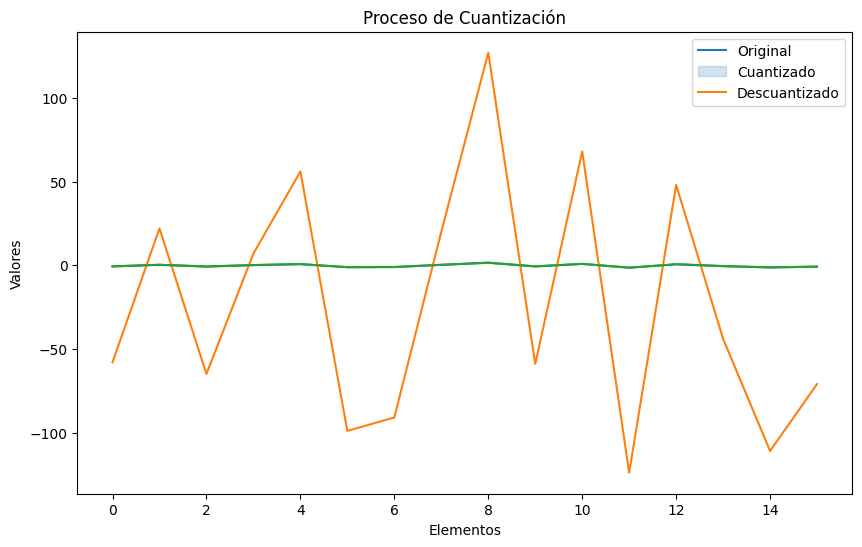

In [14]:
# Cuantización Simétrica: Ajustamos solo la escala, con zero_point en 0
scale = test_tensor.abs().max() / 127
zero_point = 0

# Cuantización y Descuantización
quantized_tensor = torch.round(test_tensor / scale).to(torch.int8)
dequantized_tensor = quantized_tensor.float() * scale

print("Tensor Cuantizado Simétrico:", quantized_tensor)
print("Tensor Descuantizado Simétrico:", dequantized_tensor)
graficar_cuantizacion(test_tensor, quantized_tensor, dequantized_tensor)

Tensor Cuantizado por Canal: tensor([[-113,   43, -127,   14],
        [  71, -127, -116,   26],
        [ 127,  -59,   68, -124],
        [  55,  -51, -127,  -81]], dtype=torch.int8)
Tensor Descuantizado por Canal: tensor([[-0.6867,  0.2613, -0.7718,  0.0851],
        [ 0.6547, -1.1711, -1.0697,  0.2398],
        [ 1.4967, -0.6953,  0.8014, -1.4613],
        [ 0.5678, -0.5265, -1.3111, -0.8362]])


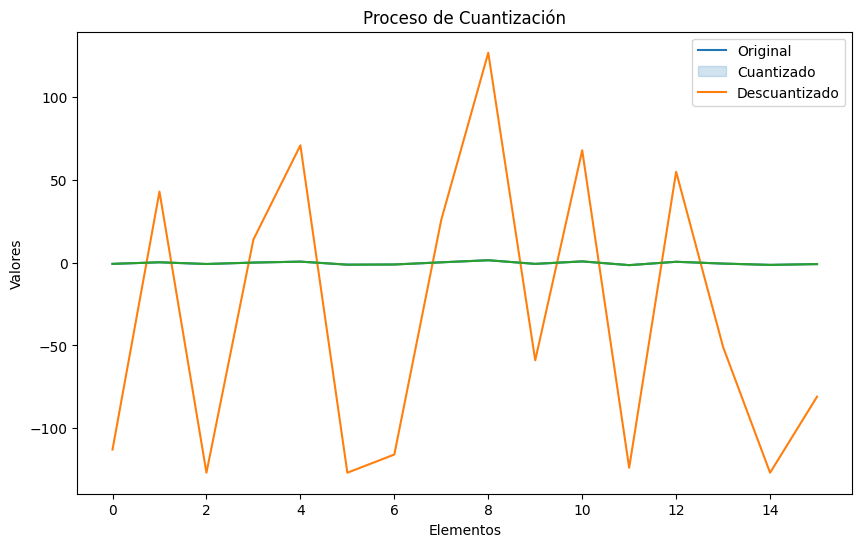

In [15]:
# Por canal:
# Calcular escala y zero point por canal
scales = test_tensor.abs().max(dim=1)[0] / 127
zero_points = torch.zeros_like(scales, dtype=torch.int8)

# Cuantización y Descuantización por Canal
quantized_tensor = torch.zeros_like(test_tensor, dtype=torch.int8)
dequantized_tensor = torch.zeros_like(test_tensor, dtype=torch.float32)
for i in range(test_tensor.size(0)):
    quantized_tensor[i] = torch.round(test_tensor[i] / scales[i]).to(torch.int8)
    dequantized_tensor[i] = quantized_tensor[i].float() * scales[i]

print("Tensor Cuantizado por Canal:", quantized_tensor)
print("Tensor Descuantizado por Canal:", dequantized_tensor)
graficar_cuantizacion(test_tensor, quantized_tensor, dequantized_tensor)

Tensor Cuantizado por Grupo: tensor([[ -75,   28,  -84,    9],
        [  71, -127, -116,   26],
        [ 127,  -59,   68, -124],
        [  48,  -44, -111,  -71]], dtype=torch.int8)
Tensor Descuantizado por Grupo: tensor([[-0.6916,  0.2582, -0.7746,  0.0830],
        [ 0.6547, -1.1711, -1.0697,  0.2398],
        [ 1.4967, -0.6953,  0.8014, -1.4613],
        [ 0.5657, -0.5185, -1.3081, -0.8367]])


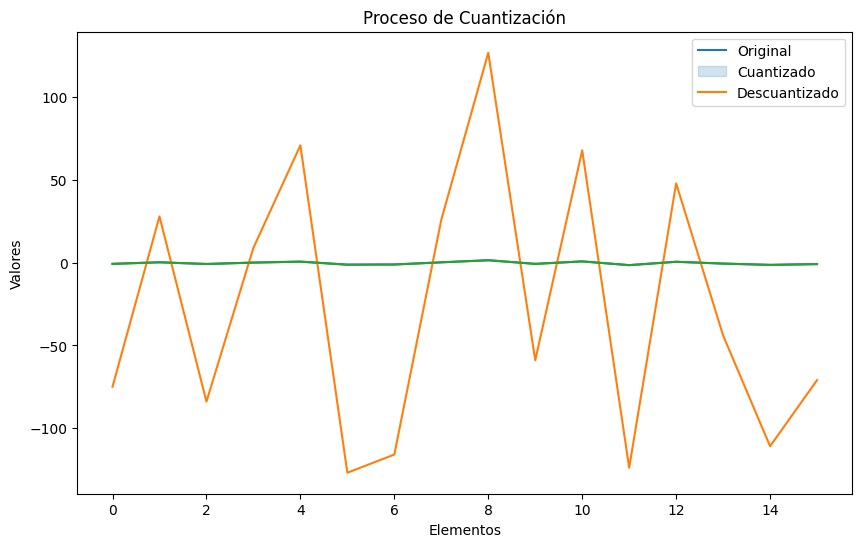

In [16]:
#per group:

group_size = 2
num_groups = test_tensor.size(0) // group_size
scales = torch.zeros(num_groups)
zero_points = torch.zeros(num_groups, dtype=torch.int8)

# Calcular escala y zero point por grupo
for g in range(num_groups):
    group_data = test_tensor[g*group_size:(g+1)*group_size].abs().max()
    scales[g] = group_data / 127

# Cuantización y Descuantización por Grupo
quantized_tensor = torch.zeros_like(test_tensor, dtype=torch.int8)
dequantized_tensor = torch.zeros_like(test_tensor, dtype=torch.float32)
for g in range(num_groups):
    quantized_tensor[g*group_size:(g+1)*group_size] = torch.round(test_tensor[g*group_size:(g+1)*group_size] / scales[g]).to(torch.int8)
    dequantized_tensor[g*group_size:(g+1)*group_size] = quantized_tensor[g*group_size:(g+1)*group_size].float() * scales[g]

print("Tensor Cuantizado por Grupo:", quantized_tensor)
print("Tensor Descuantizado por Grupo:", dequantized_tensor)
graficar_cuantizacion(test_tensor, quantized_tensor, dequantized_tensor)


Se está trabajando con Post Training Quantization. Se aplica después de entrenado/validado. Se toma lo entrenado y se cuantiza sin ajustar sus pesos.  Así también lleva cuantización de Tensors directos. Mientras que el aware training simula el impacto de la cuantización mientras se entrena. Permite compensar cuando se pierde precisión y ajusta pesos, optimizando rendimiento bajo la cuantización.

Cabe destacar que de los 3 métodos, el per channel muestra mayor fidelidad y es mejor porque es más preciso. Pero, en cuanto al equilibrio entre recursos y precisión gana per group.